In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

In [23]:
DATA_DIR = "../data"

# Load datasets
recipes_df = pd.read_csv('{}/01_Recipe_Details.csv'.format(DATA_DIR))
ingredients_df = pd.read_csv('{}/02_Ingredients.csv'.format(DATA_DIR))
compound_df = pd.read_csv('{}/03_Compound_Ingredients.csv'.format(DATA_DIR))
aliases_df = pd.read_csv('{}/04_Recipe-Ingredients_Aliases.csv'.format(DATA_DIR))

print("Recipes:", recipes_df.columns.tolist())
print("Ingredients:", ingredients_df.columns.tolist())
print("Compound:", compound_df.columns.tolist())
print("Aliases:", aliases_df.columns.tolist())

Recipes: ['Recipe ID', 'Title', 'Source', 'Cuisine']
Ingredients: ['Aliased Ingredient Name', 'Ingredient Synonyms', 'Entity ID', 'Category']
Compound: ['Compound Ingredient Name', 'Compound Ingredient Synonyms', 'entity_id', 'Contituent Ingredients', 'Category']
Aliases: ['Recipe ID', 'Original Ingredient Name', 'Aliased Ingredient Name', 'Entity ID']


In [24]:
# Unify ingredients datasets
compounds = compound_df.rename(columns={
    'entity_id': 'Entity ID',
    'Compound Ingredient Name': 'Aliased Ingredient Name',
    'Compound Ingredient Synonyms': 'Ingredient Synonyms'
})

# Combine all ingredients into one directory
all_ingredients = pd.concat([ingredients_df, compounds], ignore_index=True)

# Merge aliases with the unified ingredients
recipe_ingredients = pd.merge(aliases_df, all_ingredients, on='Entity ID', how='left', suffixes=('', '_dict'))

# Merge everything with the recipes
combined_df = pd.merge(recipe_ingredients, recipes_df, on='Recipe ID', how='left')

print(f"Raw Combined Data Shape: {combined_df.shape}")

Raw Combined Data Shape: (456279, 11)


In [25]:
print("--- Missing Values Before Cleaning ---")
print(combined_df.isnull().sum())
print(f"\nTotal Duplicated Rows Before: {combined_df.duplicated().sum()}")

# Fill missing 'Contituent Ingredients' with 'None' (since regular ingredients like salt don't have sub-ingredients)
combined_df['Contituent Ingredients'] = combined_df['Contituent Ingredients'].fillna('None')

# Drop exact duplicates so we don't double-count ingredients in recipes
combined_df = combined_df.drop_duplicates()

print("\n--- Missing Values After Cleaning ---")
print(combined_df.isnull().sum())
print(f"\nCleaned Data Shape: {combined_df.shape}")

--- Missing Values Before Cleaning ---
Recipe ID                            0
Original Ingredient Name             0
Aliased Ingredient Name              0
Entity ID                            0
Aliased Ingredient Name_dict         0
Ingredient Synonyms                  0
Category                             0
Contituent Ingredients          420957
Title                                0
Source                               0
Cuisine                              0
dtype: int64

Total Duplicated Rows Before: 4122

--- Missing Values After Cleaning ---
Recipe ID                       0
Original Ingredient Name        0
Aliased Ingredient Name         0
Entity ID                       0
Aliased Ingredient Name_dict    0
Ingredient Synonyms             0
Category                        0
Contituent Ingredients          0
Title                           0
Source                          0
Cuisine                         0
dtype: int64

Cleaned Data Shape: (452157, 11)


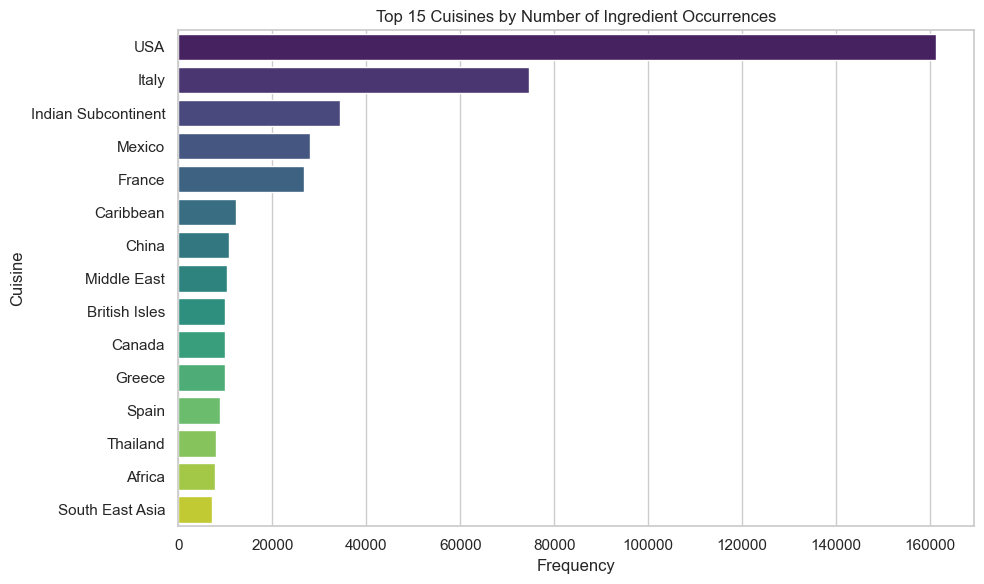

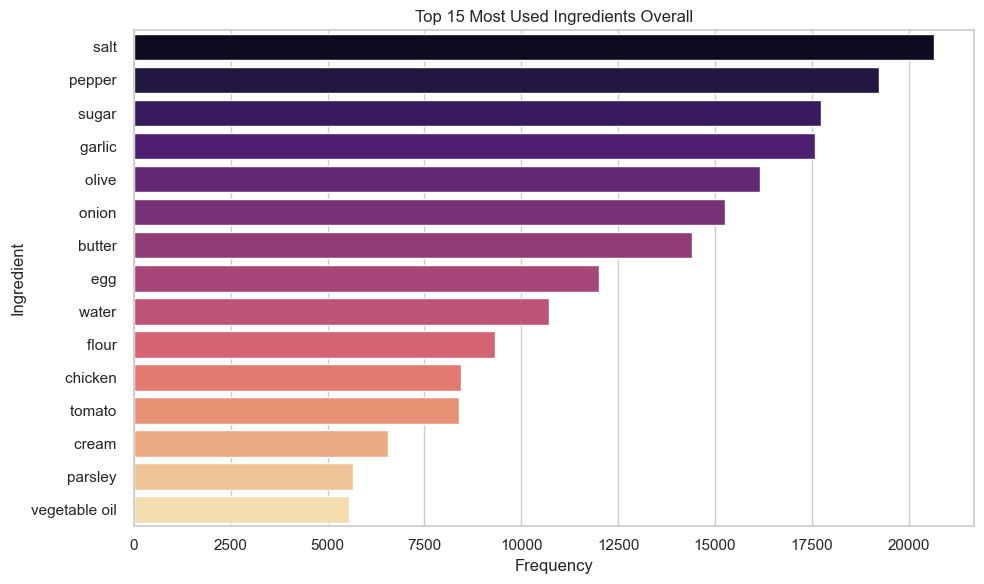

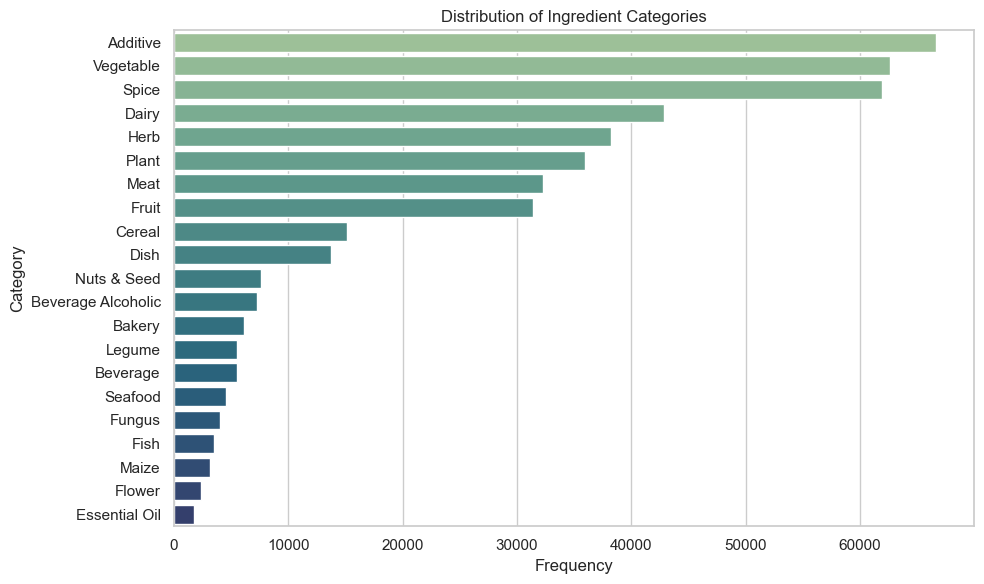

In [26]:
sns.set_theme(style="whitegrid")

# 1. Top 15 Cuisines
plt.figure(figsize=(10, 6))
top_cuisines = combined_df['Cuisine'].value_counts().head(15)
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, hue=top_cuisines.index, palette='viridis', legend=False)
plt.title('Top 15 Cuisines by Number of Ingredient Occurrences')
plt.xlabel('Frequency')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

# 2. Top 15 Ingredients Overall
plt.figure(figsize=(10, 6))
top_ingredients = combined_df['Aliased Ingredient Name'].value_counts().head(15)
sns.barplot(x=top_ingredients.values, y=top_ingredients.index, hue=top_ingredients.index, palette='magma', legend=False)
plt.title('Top 15 Most Used Ingredients Overall')
plt.xlabel('Frequency')
plt.ylabel('Ingredient')
plt.tight_layout()
plt.show()

# 3. Top Ingredient Categories
plt.figure(figsize=(10, 6))
top_categories = combined_df['Category'].value_counts()
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette='crest', legend=False)
plt.title('Distribution of Ingredient Categories')
plt.xlabel('Frequency')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

Generating charts for all 26 cuisines...


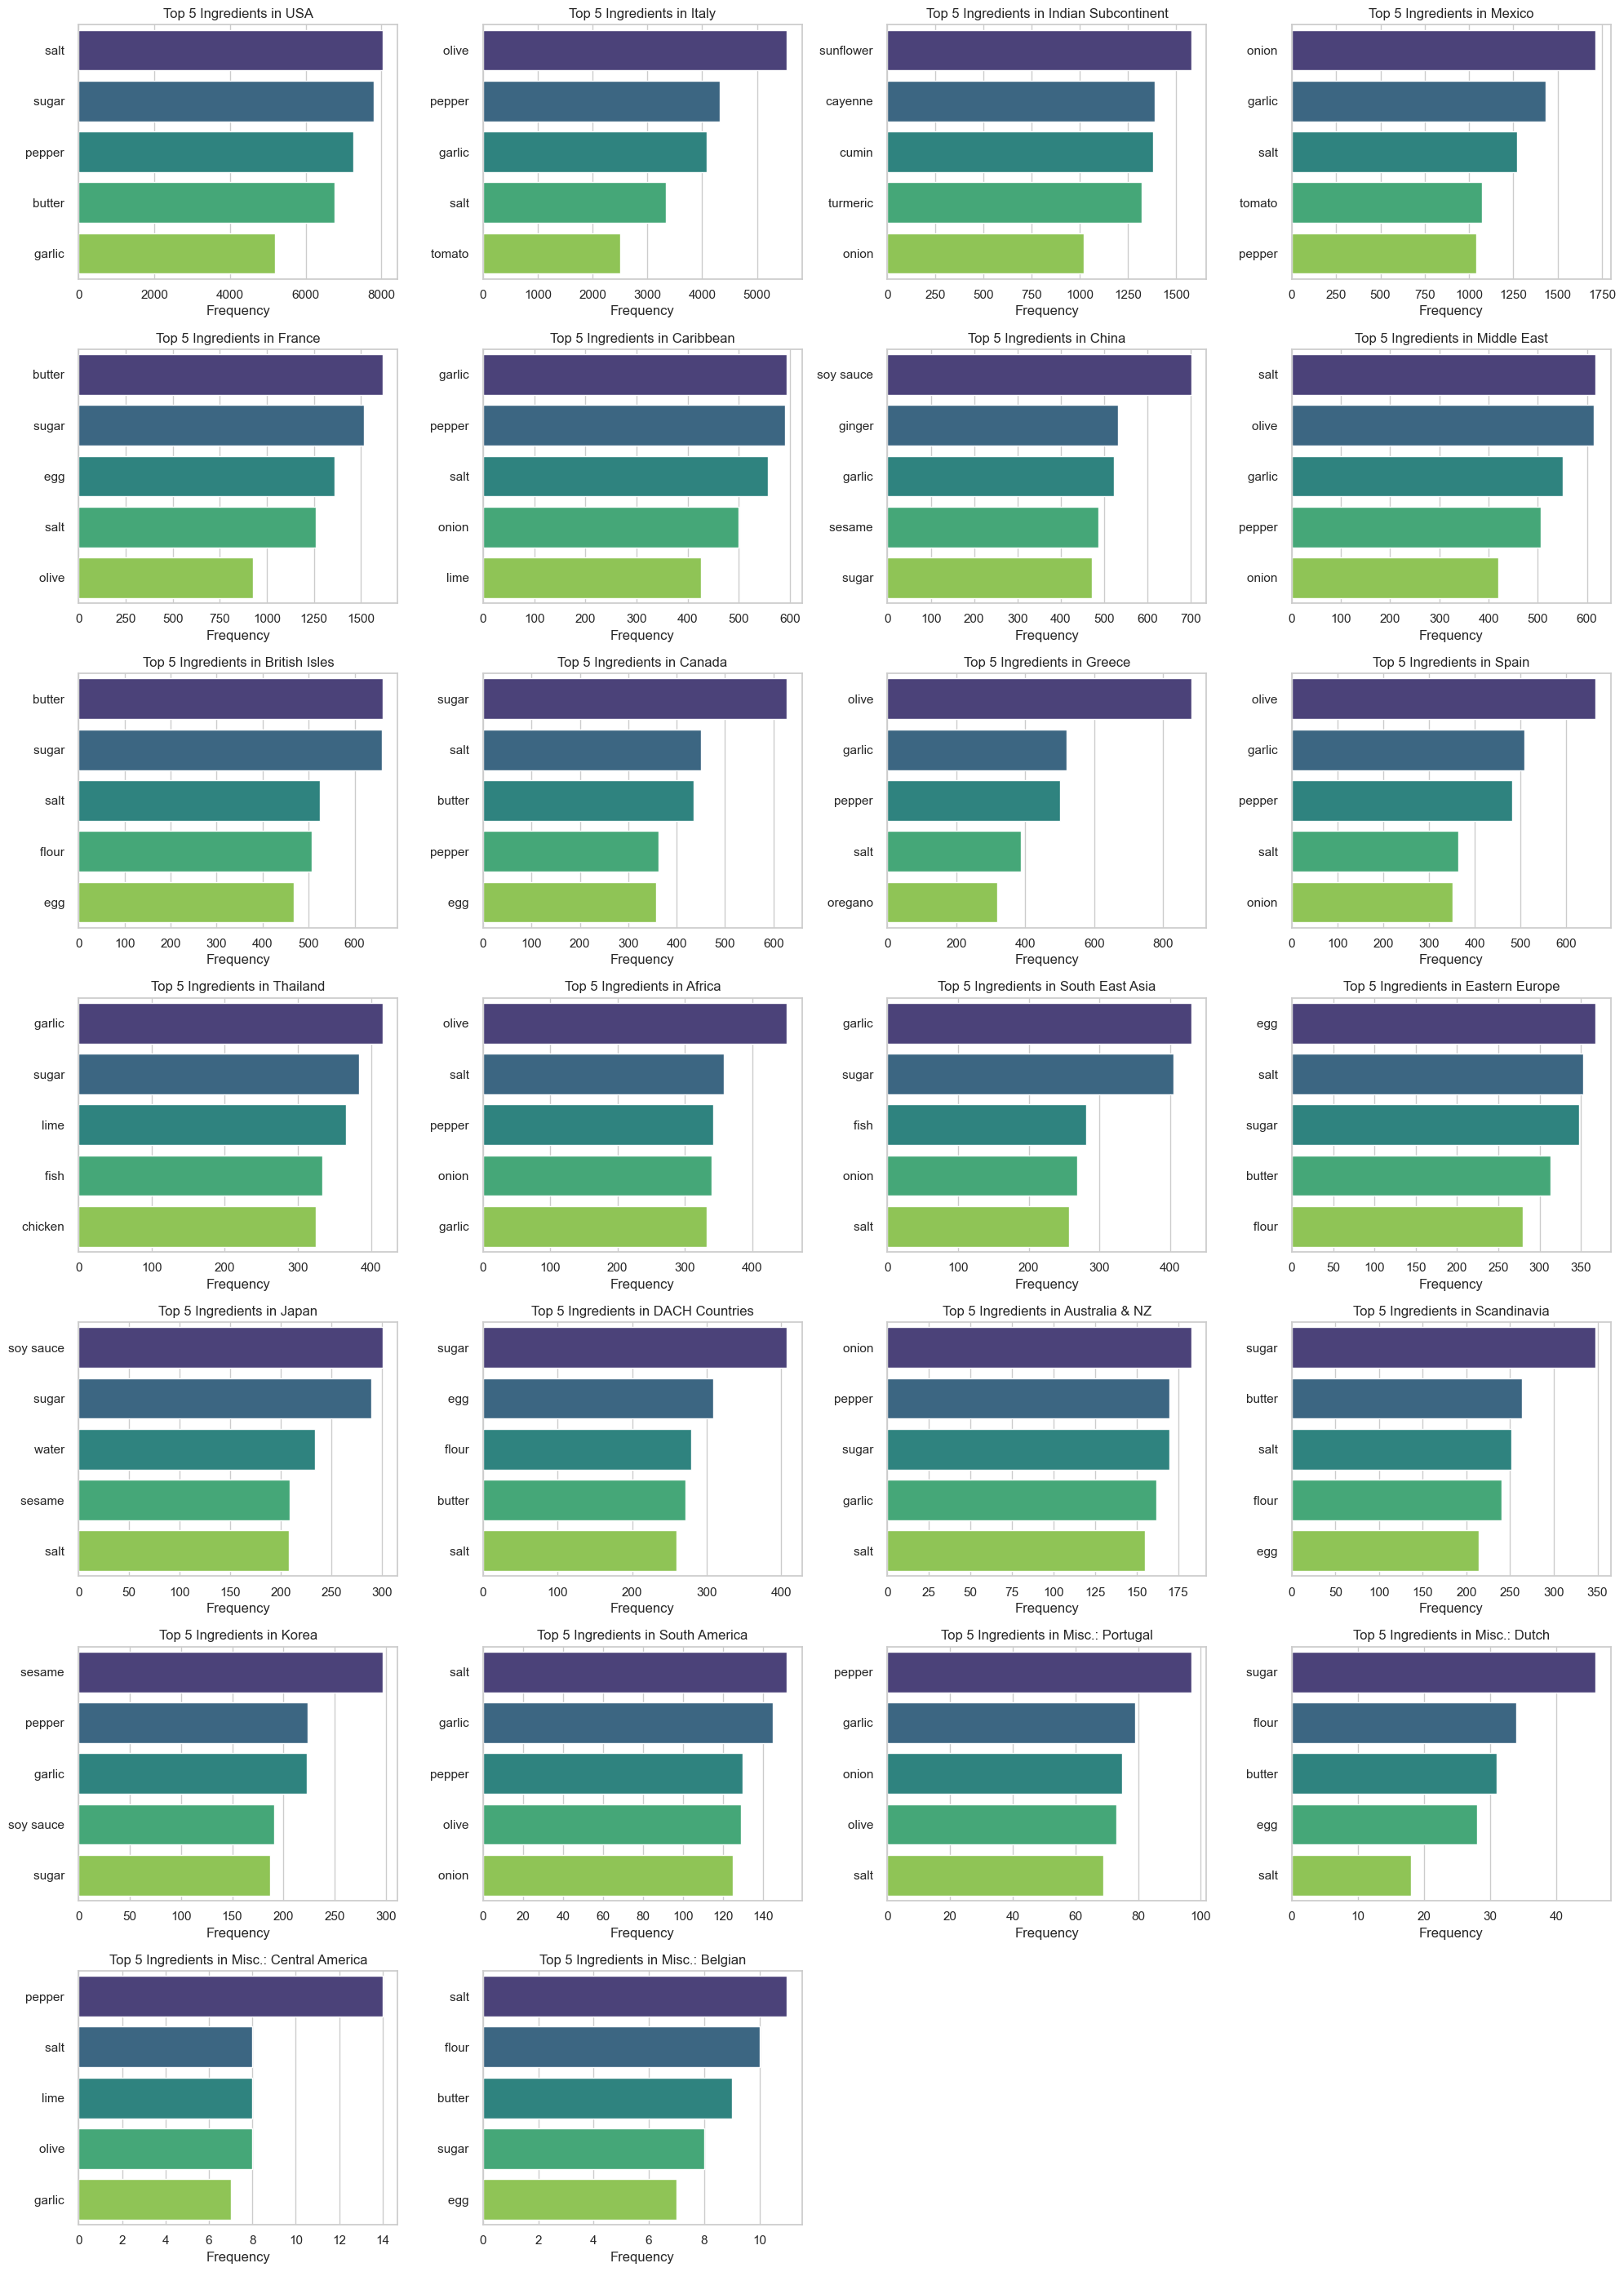

In [27]:
# Get a list of ALL cuisines in the dataset, sorted by frequency
all_cuisines = combined_df['Cuisine'].value_counts().index.tolist()
num_cuisines = len(all_cuisines)

print(f"Generating charts for all {num_cuisines} cuisines...")

# Determine grid size (4 columns wide, calculate rows dynamically)
cols = 4
rows = math.ceil(num_cuisines / cols)

# Set up the matplotlib grid based on calculated rows and columns
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), sharex=False, sharey=False)
axes = axes.flatten() # Flatten the 2D grid into a 1D list so we can loop through it easily

# Loop through every single cuisine and plot their top 5 ingredients
for i, cuisine in enumerate(all_cuisines):
    # Filter data for the specific cuisine
    subset = combined_df[combined_df['Cuisine'] == cuisine]
    
    # Get the top 5 ingredients
    top_ing = subset['Aliased Ingredient Name'].value_counts().head(5).reset_index()
    top_ing.columns = ['Ingredient', 'Count']
    
    # Create the barplot on the current axis
    sns.barplot(
        data=top_ing, 
        x='Count', 
        y='Ingredient', 
        ax=axes[i], 
        palette='viridis', 
        hue='Ingredient', 
        legend=False
    )
    
    # Formatting
    axes[i].set_title(f"Top 5 Ingredients in {cuisine}")
    axes[i].set_xlabel("Frequency")
    axes[i].set_ylabel("")

# If the grid has more slots than we have cuisines, hide the empty subplots
for j in range(num_cuisines, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlap and show the massive chart!
plt.tight_layout()
plt.show()

Generating category charts for all 26 cuisines...


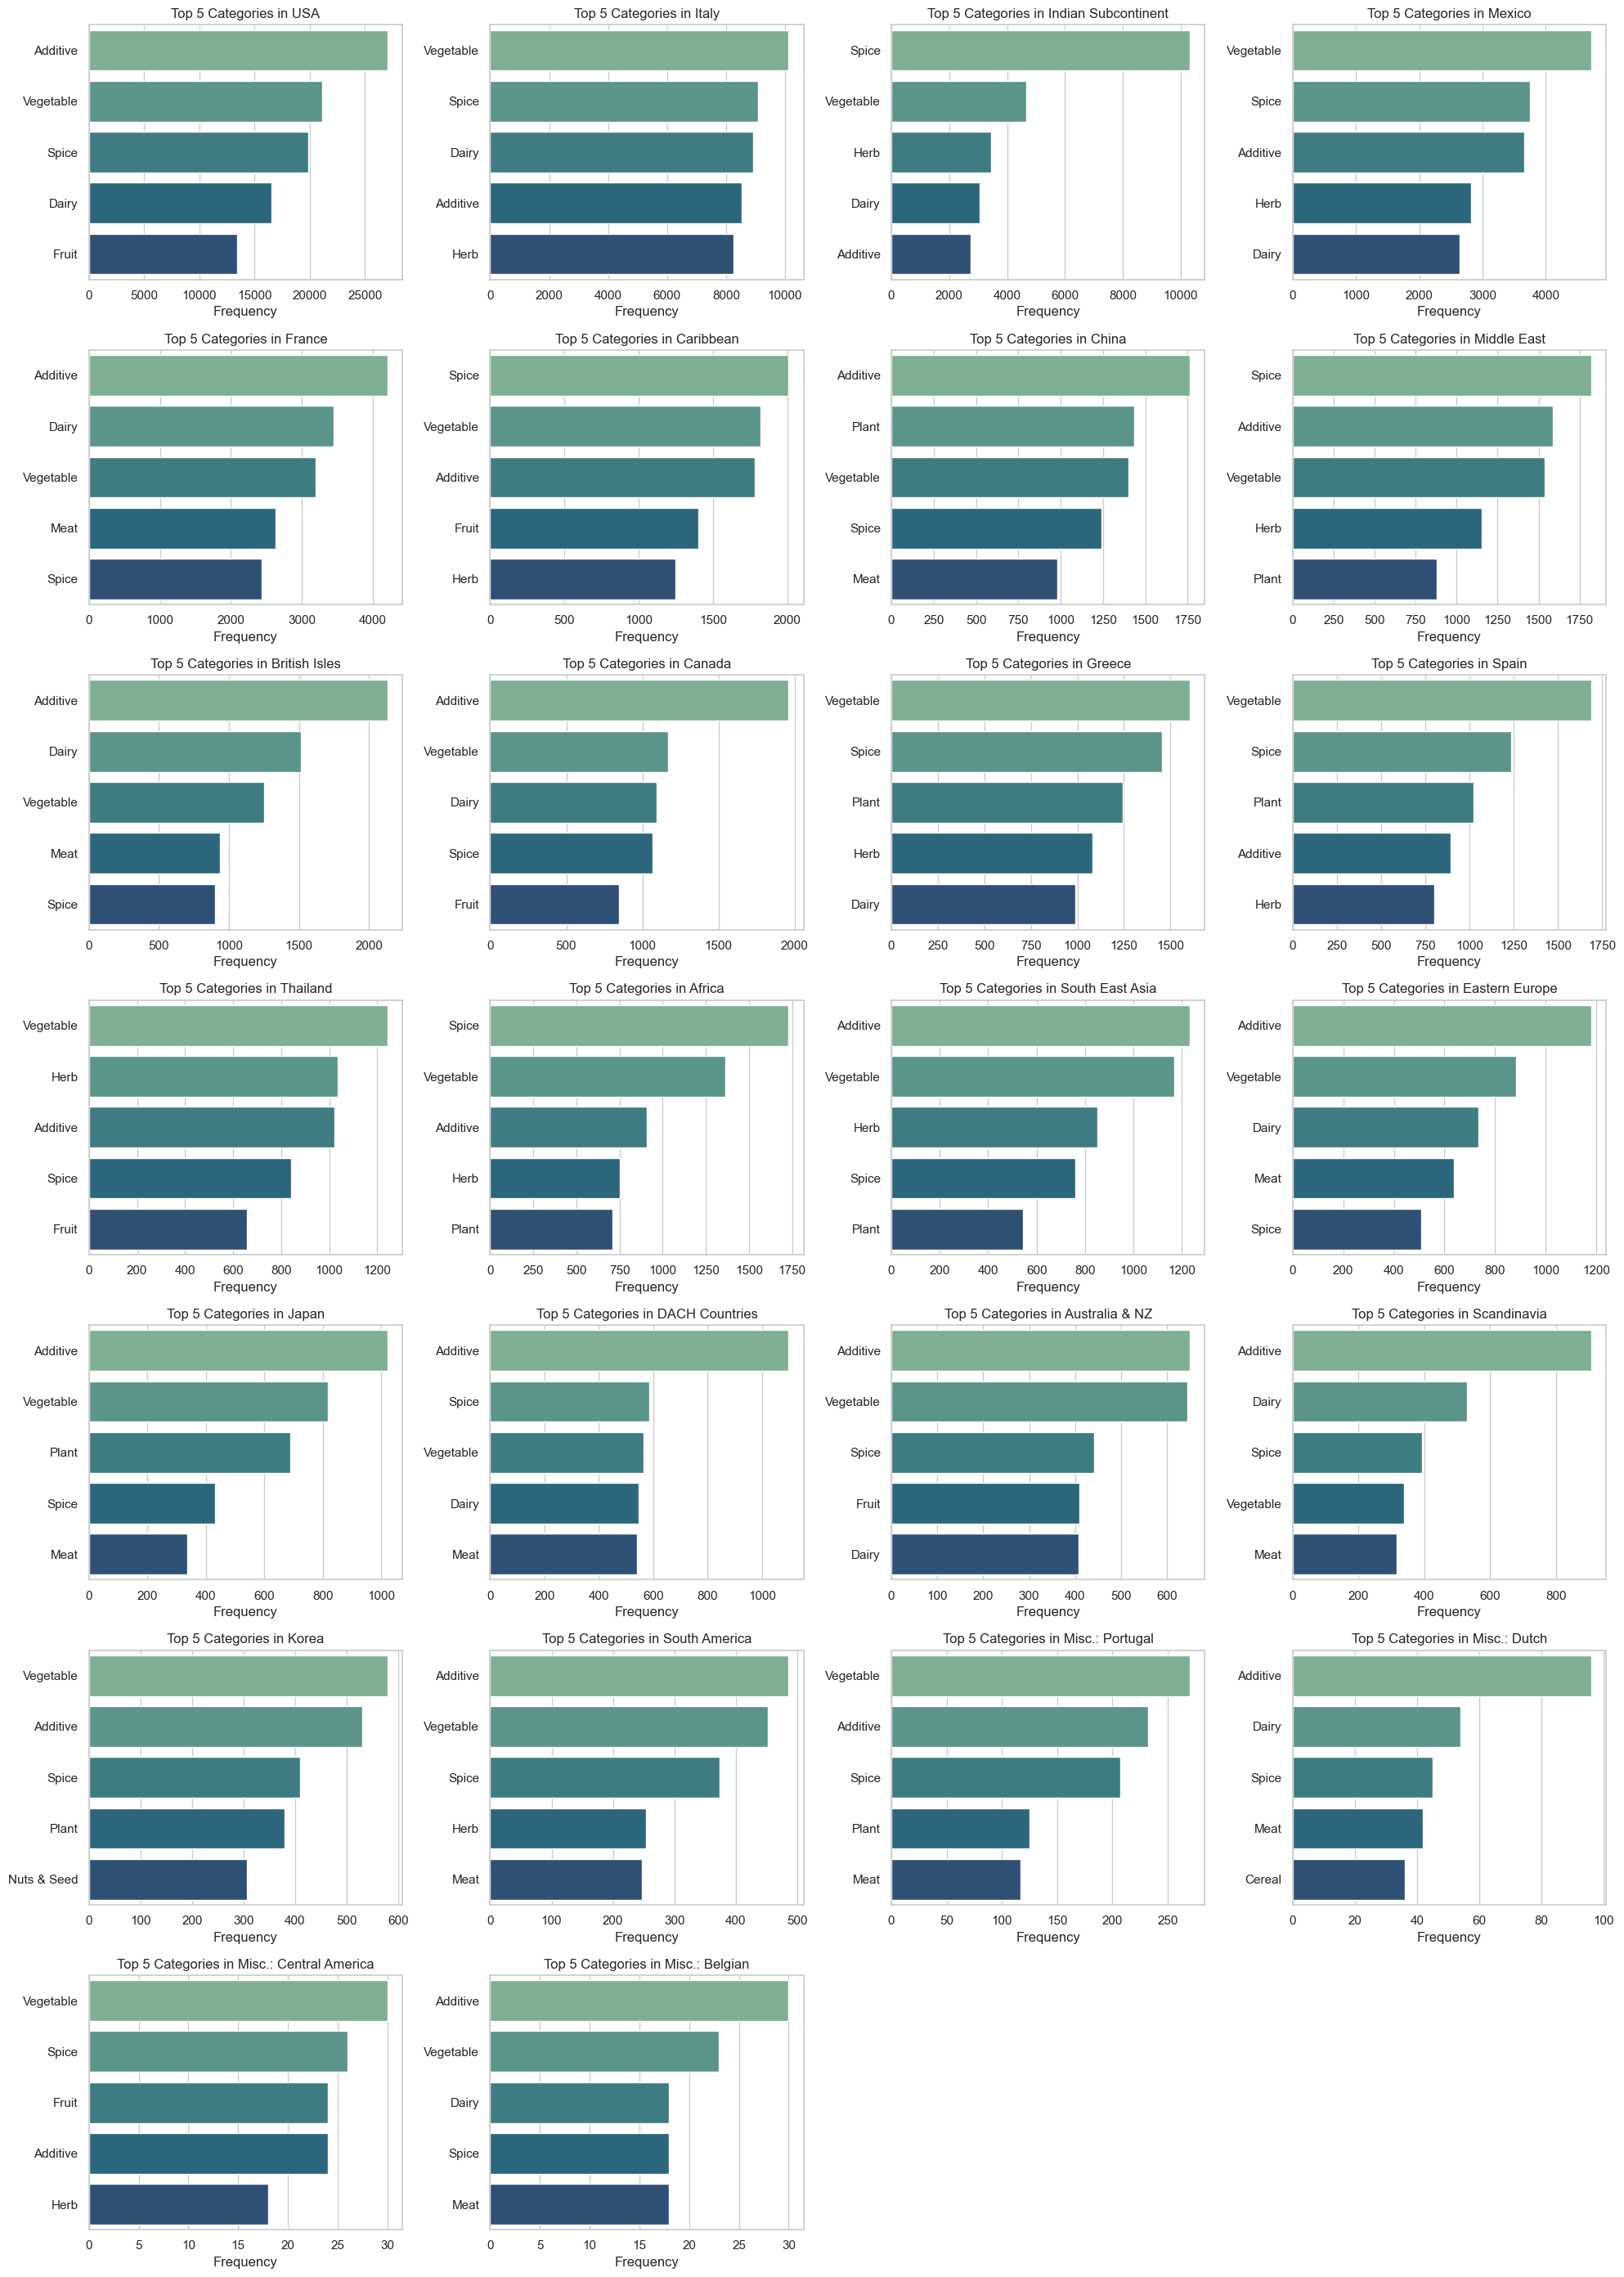

In [28]:
# Get a list of ALL cuisines in the dataset, sorted by frequency
all_cuisines = combined_df['Cuisine'].value_counts().index.tolist()
num_cuisines = len(all_cuisines)

print(f"Generating category charts for all {num_cuisines} cuisines...")

# Determine grid size (4 columns wide, calculate rows dynamically)
cols = 4
rows = math.ceil(num_cuisines / cols)

# Set up the matplotlib grid based on calculated rows and columns
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), sharex=False, sharey=False)
axes = axes.flatten()

# Loop through every single cuisine and plot their top 5 categories
for i, cuisine in enumerate(all_cuisines):
    # Filter data for the specific cuisine
    subset = combined_df[combined_df['Cuisine'] == cuisine]
    
    # Get the top 5 ingredient CATEGORIES
    top_cat = subset['Category'].value_counts().head(5).reset_index()
    top_cat.columns = ['Category', 'Count']
    
    # Create the barplot on the current axis
    # We use a different color palette ('crest') so it looks distinct from the ingredient charts!
    sns.barplot(
        data=top_cat, 
        x='Count', 
        y='Category', 
        ax=axes[i], 
        palette='crest', 
        hue='Category', 
        legend=False
    )
    
    # Formatting
    axes[i].set_title(f"Top 5 Categories in {cuisine}")
    axes[i].set_xlabel("Frequency")
    axes[i].set_ylabel("")

# Hide any empty subplots at the end of the grid
for j in range(num_cuisines, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlap and display the charts
plt.tight_layout()
plt.show()

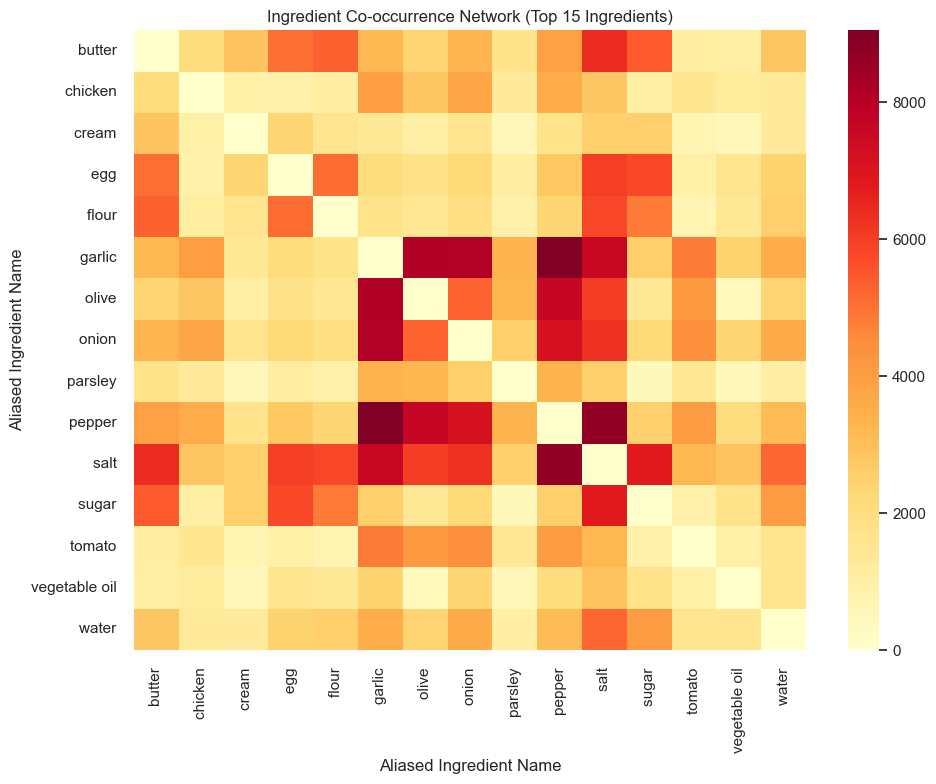

In [29]:
# Get the top 15 most used ingredients overall
top_15_ing = combined_df['Aliased Ingredient Name'].value_counts().head(15).index.tolist()

# Filter the dataset to only include these ingredients
co_df = combined_df[combined_df['Aliased Ingredient Name'].isin(top_15_ing)][['Recipe ID', 'Aliased Ingredient Name']].copy()
co_df['value'] = 1

# Create a pivot table: Rows are recipes, Columns are ingredients, 1 means present, 0 means absent
pivot = co_df.pivot_table(index='Recipe ID', columns='Aliased Ingredient Name', values='value', fill_value=0)

# The dot product of the transposed matrix creates a Co-occurrence Matrix!
co_matrix = pivot.T.dot(pivot)

# Plot Heatmap
plt.figure(figsize=(10, 8))
# We set the diagonal to zero so the color scale isn't skewed by an ingredient pairing with itself
np.fill_diagonal(co_matrix.values, 0)
sns.heatmap(co_matrix, cmap='YlOrRd', annot=False)
plt.title("Ingredient Co-occurrence Network (Top 15 Ingredients)")
plt.tight_layout()
plt.show()

# Export for D3 Network Graphs
#co_matrix.to_csv('d3_ingredient_cooccurrence.csv')

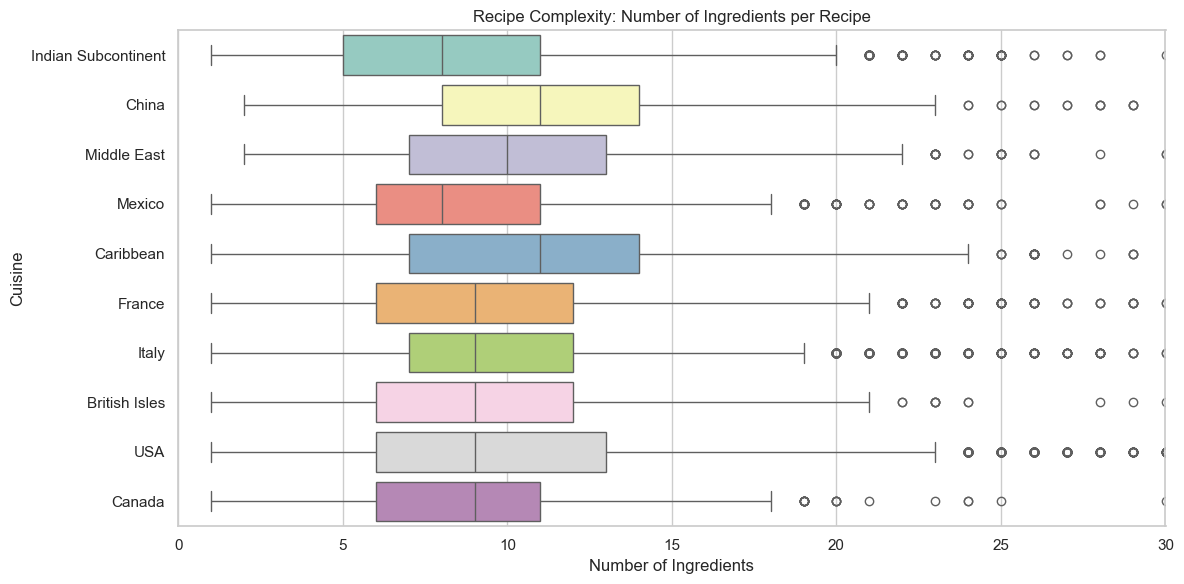

In [30]:
# Count how many ingredients are in every single recipe
recipe_counts = combined_df.groupby(['Recipe ID', 'Cuisine']).size().reset_index(name='Ingredient Count')

# Filter to the top 10 cuisines so the chart is easy to read
top_10 = combined_df['Cuisine'].value_counts().head(10).index.tolist()
recipe_counts_top10 = recipe_counts[recipe_counts['Cuisine'].isin(top_10)]

plt.figure(figsize=(12, 6))
# Boxplot shows the median, interquartile range, and outliers for each cuisine
sns.boxplot(data=recipe_counts_top10, x='Ingredient Count', y='Cuisine', palette='Set3', hue='Cuisine', legend=False)
plt.title("Recipe Complexity: Number of Ingredients per Recipe")
plt.xlabel("Number of Ingredients")
plt.xlim(0, 30) # Ignore huge outliers for a cleaner chart
plt.tight_layout()
plt.show()

# Save aggregated stats for D3
#complexity_stats = recipe_counts.groupby('Cuisine')['Ingredient Count'].agg(['mean', 'median', 'max', 'min']).reset_index()
#complexity_stats.to_csv('d3_recipe_complexity.csv', index=False)